# Evaporative Cooling — Harmonic Oscillator Trap

The density of states gives polylogarithm orders $\nu = 3$ (particle number)
and $\nu = 4$ (energy). Energy prefactor $d/2 = 3$.

**Reference:** Arvizu-Velázquez et al., arXiv (2026).

In [1]:
import numpy as np
import mpmath as mp
import math
import scipy.special as ss
from matplotlib import pyplot as plt
import time

from evap_cool_utils import (
    ConstantsSI, ConstantsEV,
    g_tilde, g_bar,
    newton_raphson_1var, newton_raphson_2var_fused, newton_raphson_2var_fused_real,
    mb_particle_number, mb_temperature_box, mb_temperature_quadrupole, mb_temperature_oscillator,
    create_result_dict, create_mb_result_dict,
    build_cutoff_schedule, initialize_boson_state, initialize_mb_state,
    run_quantum_evaporation, run_mb_evaporation,
    plot_combined_overview, plot_individual_panels,
)

## 1. Physical Parameters

In [2]:
h = ConstantsEV.h; hb = ConstantsEV.hbar; kB = ConstantsEV.kB; m = ConstantsEV.m_Na23
omega = 2 * np.pi * 100
N0 = 1e7; T0 = 5e-5

def dos_prefactor(T):
    return (kB * T)**3 / (hb * omega)**3

## 2. Equation of State

In [3]:
def N_equation_boson(x):
    return dos_prefactor(T0) * mp.polylog(3, mp.exp(x)) - N0
def dN_equation_boson(x):
    return dos_prefactor(T0) * mp.polylog(2, mp.exp(x))
def N_equation_fermion(x):
    return -dos_prefactor(T0) * mp.polylog(3, -mp.exp(x)) - N0
def dN_equation_fermion(x):
    return -dos_prefactor(T0) * mp.polylog(2, -mp.exp(x))

## 3. Compute Initial Chemical Potentials

In [4]:
start = time.time()
alpha_b = newton_raphson_1var(N_equation_boson, dN_equation_boson, -12, -11.5, dx=1e-5)
if alpha_b is None: raise RuntimeError("Root not found for boson μ")
mu0_b = alpha_b * kB * T0
E0_b = float(3 * N0 * kB * T0 * (mp.polylog(4, mp.exp(alpha_b)) / mp.polylog(3, mp.exp(alpha_b))))
print(f"Bosons:   α = {alpha_b:.10f},  μ = {mu0_b:.6e},  E₀ = {E0_b:.6e}  [{time.time()-start:.1f}s]")

start = time.time()
alpha_f = newton_raphson_1var(N_equation_fermion, dN_equation_fermion, -12, -11.5, dx=1e-5)
if alpha_f is None: raise RuntimeError("Root not found for fermion μ")
mu0_f = alpha_f * kB * T0
E0_f = float(3 * N0 * kB * T0 * (mp.polylog(4, -mp.exp(alpha_f)) / mp.polylog(3, -mp.exp(alpha_f))))
print(f"Fermions: α = {alpha_f:.10f},  μ = {mu0_f:.6e},  E₀ = {E0_f:.6e}  [{time.time()-start:.1f}s]")

Bosons:   α = -11.6358656710,  μ = -5.013507e-08,  E₀ = 1.292599e-01  [2.5s]
Fermions: α = -11.6358634602,  μ = -5.013506e-08,  E₀ = 1.292601e-01  [2.6s]


## 4. Build Cut-off Schedule & Initialize Data

In [5]:
# ── Conservative ──
Q0 = 5e-4
dQ = 1e-8
N_STEPS = 10000
dT_nr  = T0 * 1e-12           # ≈ 5e-17
dmu_nr = abs(mu0_b) * 1e-12   # ≈ 5e-20
Q_schedule = build_cutoff_schedule(Q0, dQ, N_STEPS)
results_b = create_result_dict(); results_f = create_result_dict(); results_mb = create_mb_result_dict()
initialize_boson_state(results_b, N0, T0, mu0_b, E0_b)
initialize_boson_state(results_f, N0, T0, mu0_f, E0_f)
initialize_mb_state(results_mb, N0, T0)
results_b['Q'] = Q_schedule; results_f['Q'] = Q_schedule
results_mb['Q'] = build_cutoff_schedule(Q0, dQ, N_STEPS + 1)

## 5. Fused Truncated Distribution Functions

For the harmonic oscillator ($\nu = 6$), the recurrences are:

$$\frac{N_i}{N_{i-1}} = \frac{\tilde{g}_{3}}{g_{3}}
  - \frac{2}{\sqrt{\pi}}\,\eta^{1/2}\,\frac{\bar{g}_{2}}{g_{3}}$$

$$\frac{E_i}{E_{i-1}} = \frac{\tilde{g}_{4}}{g_{4}}
  - \frac{2}{\sqrt{\pi}}\,\eta^{1/2}\,\frac{\bar{g}_{3}}{g_{4}}
  - \frac{4}{6\sqrt{\pi}}\,\eta^{3/2}\,\frac{\bar{g}_{2}}{g_{4}}$$

In [6]:
def _make_truncated_NE_osc(sign):
    def truncated_NE(Ni, Ti, Mui, Ei, Qc):
        eta_c = Qc / Ti
        alpha = Mui / (kB * Ti)
        z_full = sign * mp.exp(alpha)

        gt_3 = g_tilde(3, alpha, eta_c, sign)
        gt_4 = g_tilde(4, alpha, eta_c, sign)
        g3_full = mp.polylog(3, z_full)
        g4_full = mp.polylog(4, z_full)
        gb_2 = g_bar(2, alpha, eta_c, sign)
        gb_3 = g_bar(3, alpha, eta_c, sign)

        g3_norm = sign * g3_full
        g4_norm = sign * g4_full
        c1 = 2 * mp.sqrt(eta_c / mp.pi)
        c2 = (4 * eta_c**1.5) / (6 * mp.sqrt(mp.pi))

        N1 = (gt_3 / g3_norm - c1 * gb_2 / g3_norm) * Ni
        E1 = (gt_4 / g4_norm - c1 * gb_3 / g4_norm - c2 * gb_2 / g4_norm) * Ei

        return (N1, E1)
    return truncated_NE

truncated_NE_boson_osc   = _make_truncated_NE_osc(+1)
truncated_NE_fermion_osc = _make_truncated_NE_osc(-1)

## 6. Newton-Raphson (2-Variable) with Precomputed Polylogs

In [7]:
def _make_nr_solver_osc(sign):
    def solver(T_init, mu_init, dT, dmu, Ni, Ei):
        def jacobian(T, mu):
            z = sign * mp.exp(mu / (kB * T))
            g2 = mp.polylog(2, z); g3 = mp.polylog(3, z); g4 = mp.polylog(4, z)
            C = dos_prefactor(T)
            f_val = sign * C * g3 - Ni
            g_val = 3 * Ni * kB * T * (g4 / g3) - Ei
            f_y_val = sign * (kB * T)**2 / (hb * omega)**3 * g2
            C_T = (kB * T)**2 / (hb * omega)**3
            f_x_val = sign * C_T * (3 * kB * T * g3 - mu * g2) / T
            g_y_val = 3 * Ni * (1 - g2 * g4 / g3**2)
            g_x_val = 3 * Ni * (-mu / T + mu * g2 * g4 / (T * g3**2) + kB * g4 / g3)
            return (f_val, g_val, f_x_val, f_y_val, g_x_val, g_y_val)
        return newton_raphson_2var_fused(jacobian, T_init, mu_init, dT, dmu)
    return solver

nr_solver_boson_osc   = _make_nr_solver_osc(+1)
nr_solver_fermion_osc = _make_nr_solver_osc(-1)

## 7. Run Evaporation Simulations

In [8]:
print("Running boson evaporation...")
start = time.time()
run_quantum_evaporation(results_b, truncated_NE_boson_osc, nr_solver_boson_osc, N0, N_STEPS, dT_nr, dmu_nr)
print(f"  Done in {time.time()-start:.1f}s")

print("Running fermion evaporation...")
start = time.time()
run_quantum_evaporation(results_f, truncated_NE_fermion_osc, nr_solver_fermion_osc, N0, N_STEPS, dT_nr, dmu_nr)
print(f"  Done in {time.time()-start:.1f}s")

print("Running Maxwell-Boltzmann evaporation...")
start = time.time()
run_mb_evaporation(results_mb, mb_particle_number, mb_temperature_oscillator, N0, N_STEPS + 1)
print(f"  Done in {time.time()-start:.1f}s")

Running boson evaporation...
  Done in 32.8s
Running fermion evaporation...
  Done in 34.3s
Running Maxwell-Boltzmann evaporation...
  Done in 0.1s


## 8. Results

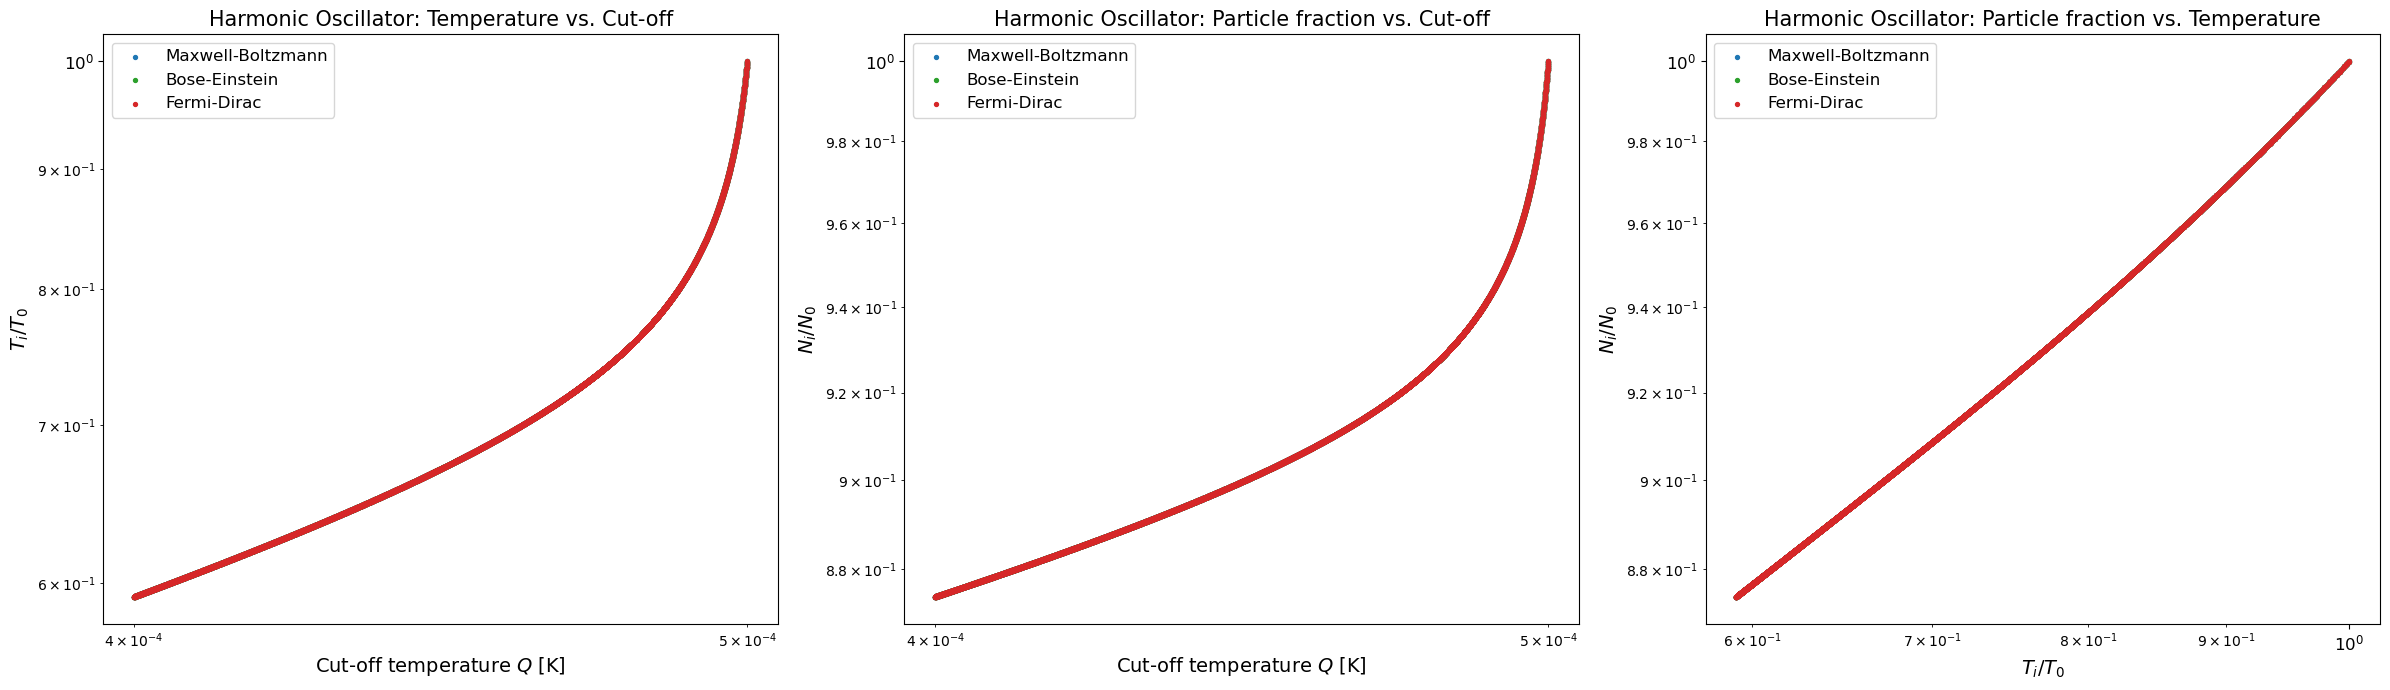

In [9]:
fig = plot_combined_overview(results_b, results_f, results_mb, "Harmonic Oscillator")
plt.show()

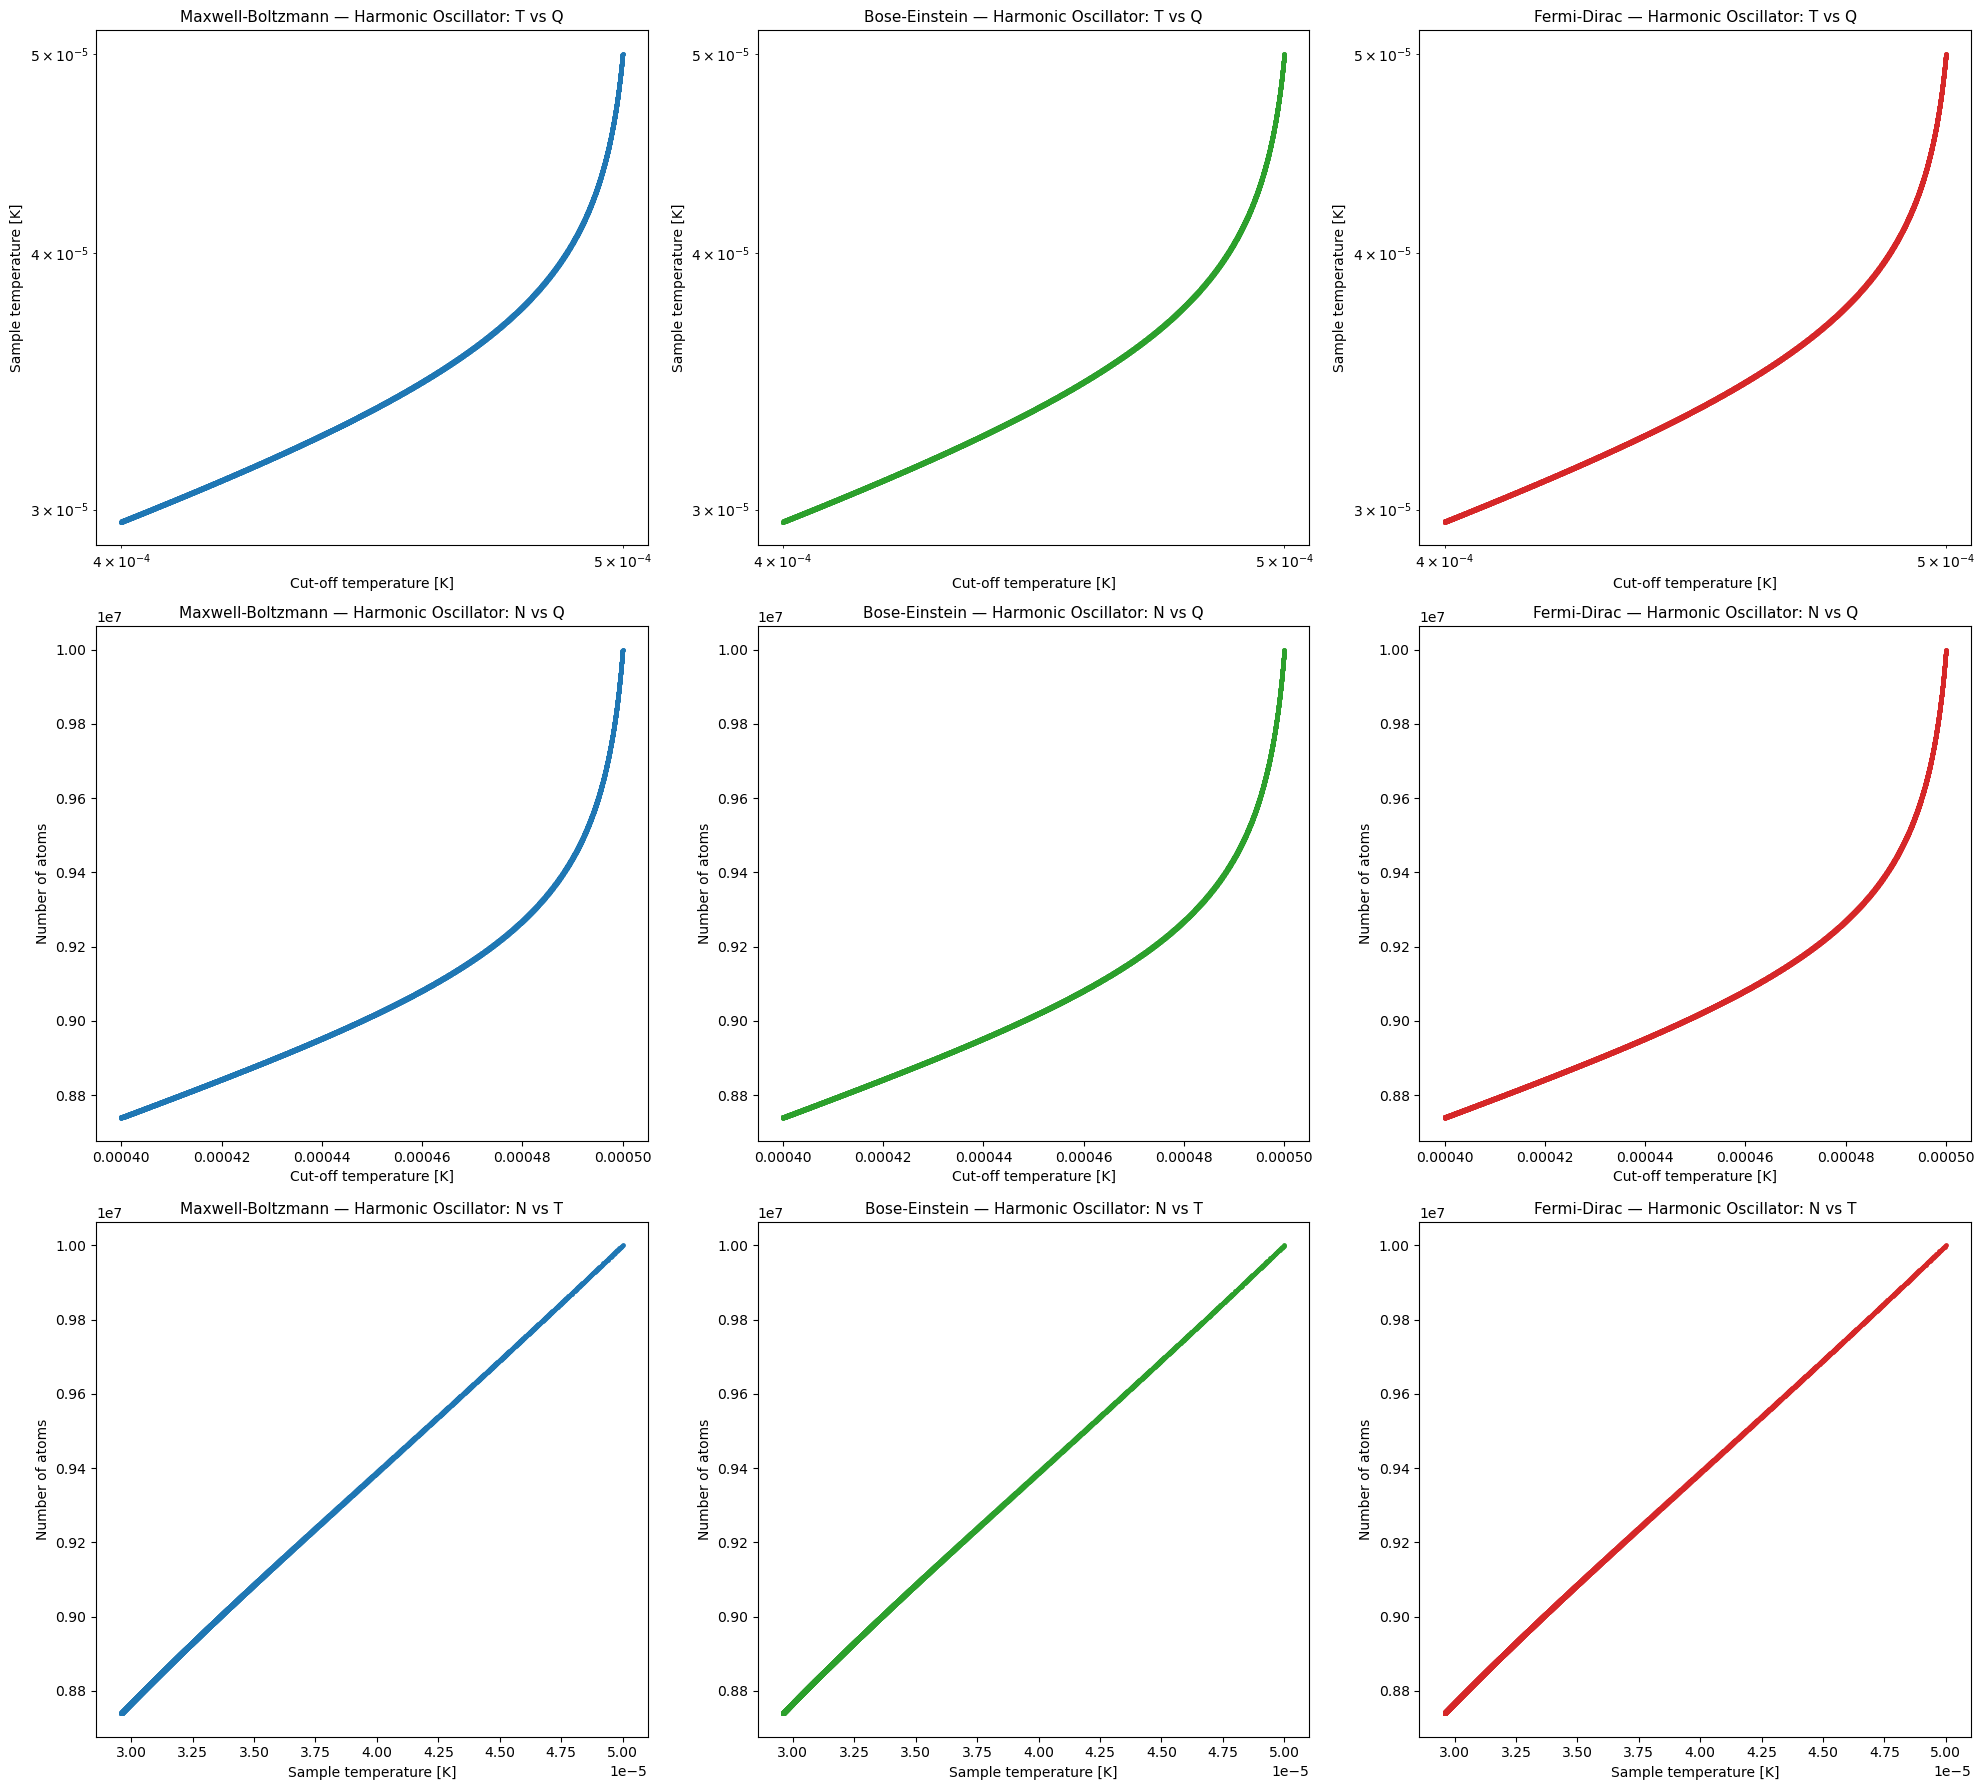

In [10]:
fig = plot_individual_panels(results_b, results_f, results_mb, "Harmonic Oscillator")
plt.show()